importing libraries

In [485]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error

In [486]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


CONNECT TO THE SQL DATABASE

In [487]:
import sqlite3
conn = sqlite3.connect("../ShiftData.db.db")

shift_data = pd.read_sql("SELECT * FROM shiftperformance", conn)

shift_data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


LET CHECK THE SHAPE OF DATASET

In [488]:
shift_data.shape

(296334, 31)

DAY 2
1. listing all the columns in the dataset

2. The shape of the data

3. The information  about the datatype of each columns

4. Checking for missing values

5. checking the statistical distribution of the numerical values of our dataset 

6. Checking for duplicates in our dataset.

Listing all the columns in the dataset

In [489]:
shift_data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [490]:
# Checking the datatype for each columns

shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

identify the target variable

is the shift_efficiency_score

Numerical variables are floats (8) and int64(7)

Categorical Variables are the object (16)

TimeStamp Variables

In [491]:
# identify data quality issues
 
# Checking for dulpicates

shift_data.duplicated().sum()

np.int64(0)

In [492]:
# Checking for missing values

shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 



Filling the missing values for the Temperature, humidity, timestamp 

NOTE you can not perform mean on timestamp but we convert the timestamp to datetime RIGHT You using maen to fill fill missing value 

of columns of temperature and humidity

In [493]:

shift_data["data"] = pd.to_datetime(shift_data["date"])

shift_data = shift_data.sort_values(by="date")

shift_data["temperature"] = shift_data["temperature"].fillna(method="ffill").fillna(shift_data["temperature"].mean())
shift_data["humidity"] = shift_data["humidity"].fillna(method="ffill").fillna(shift_data["humidity"].mean())


# fill the timestamp
shift_data["timestamp"] = shift_data["timestamp"].fillna(method="ffill")



C:\Users\pc\AppData\Local\Temp\ipykernel_9836\3012512718.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["temperature"] = shift_data["temperature"].fillna(method="ffill").fillna(shift_data["temperature"].mean())
C:\Users\pc\AppData\Local\Temp\ipykernel_9836\3012512718.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["humidity"] = shift_data["humidity"].fillna(method="ffill").fillna(shift_data["humidity"].mean())
C:\Users\pc\AppData\Local\Temp\ipykernel_9836\3012512718.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data["timestamp"] = shift_data["timestamp"].fillna(method="ffill")


In [494]:
# let check our result
shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

Note you cannot perform average on timestamp becos is  a date

In [495]:
# fill the categorical maintenance field

shift_data["issue_type"] = shift_data["issue_type"].fillna("no issue")

shift_data["maintenance_downtime"] = shift_data["maintenance_downtime"].fillna(0)
shift_data["resolved_by"] = shift_data["resolved_by"].fillna("no issue_resolved")
shift_data = shift_data.drop(columns=["maintenance_id"])

shift_data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
data                      0
dtype: int64

In [496]:
# Let do Statistical distribution of dataset

shift_data.describe()

,shift_id,production_id,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_downtime,qc_id,temperature,humidity,data
count,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.00000,296334.000000,296334.000000,296334
mean,2.048142,6777.751567,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,20.821531,138756.82872,20.893584,44.579900,2024-02-14 16:00:58.312579584
min,1.000000,1.000000,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,0.000000,1.00000,17.000000,30.000000,2024-01-01 00:00:00
25%,1.000000,3350.000000,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,0.000000,70076.25000,19.900000,38.700000,2024-01-23 00:00:00
50%,2.000000,6747.000000,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,0.000000,139062.50000,20.900000,44.500000,2024-02-14 00:00:00
75%,3.000000,10200.750000,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,46.530000,207680.75000,21.900000,50.300000,2024-03-08 18:00:00
max,3.000000,13650.000000,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 00:00:00
std,0.807365,3952.136116,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,28.682994,79691.21252,1.527814,7.744955,NaN


EXPLOARTORY DATA ANALYSIS

1. NUMERICAL VARIABLE ANALYSIS
NOW separate numerical columns

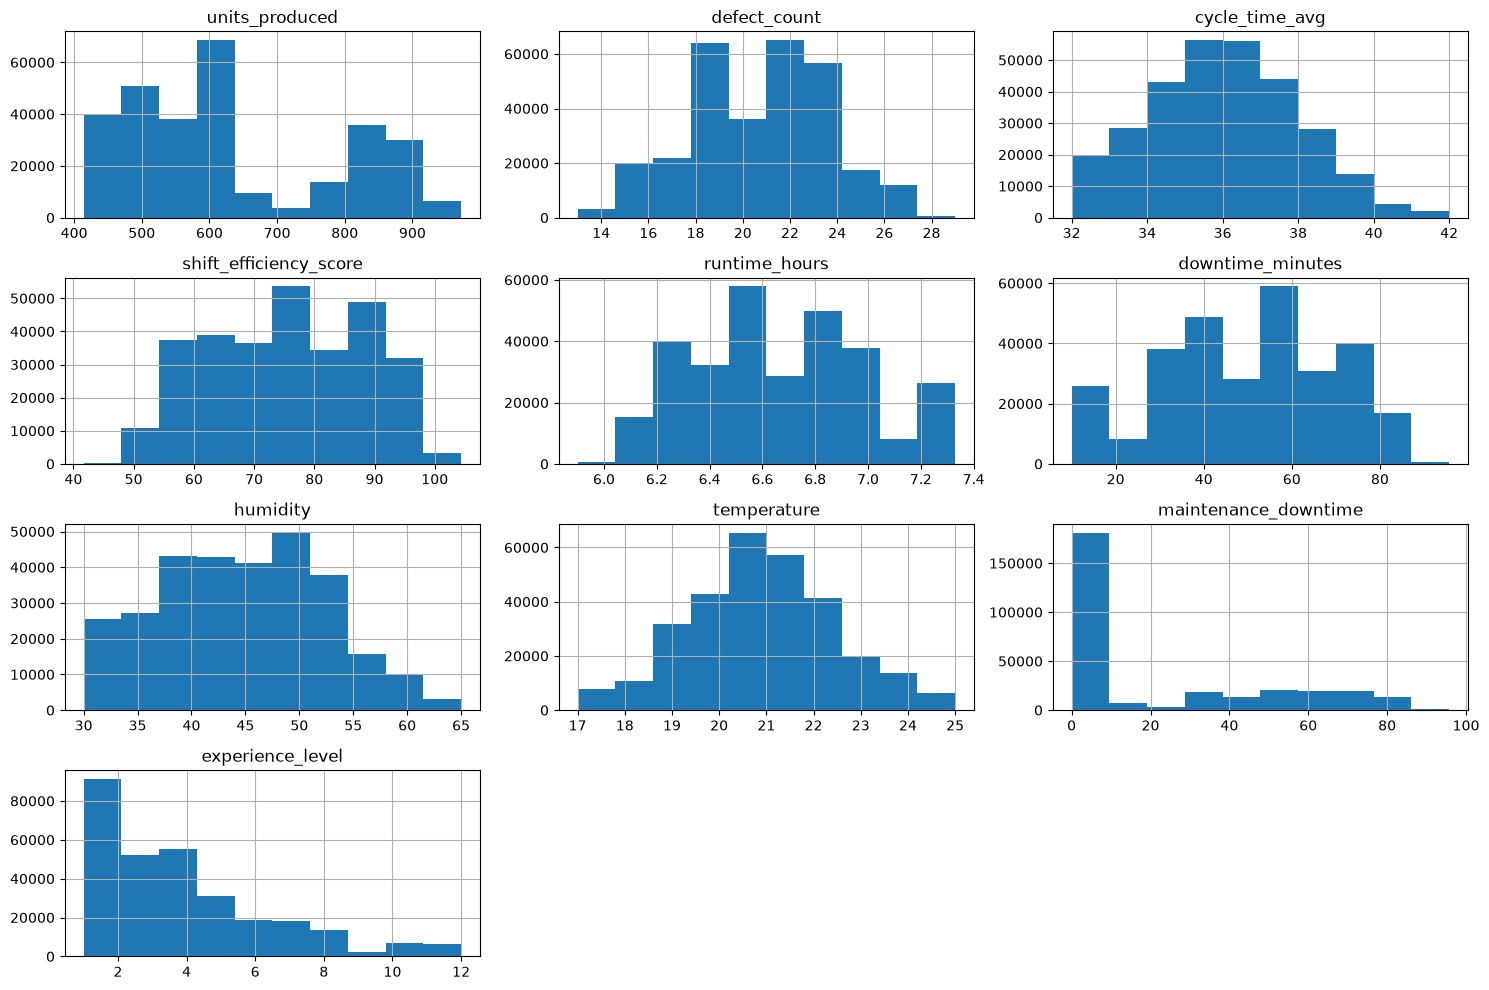

In [497]:
numerical_columns = [

    "units_produced","defect_count","cycle_time_avg","shift_efficiency_score",
    "runtime_hours","downtime_minutes","humidity","temperature","maintenance_downtime",
    "experience_level"
]

shift_data[numerical_columns].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

Assigmt a business interpretation of the graph and submit on the IMS BOARD

using boxplot to check outliers on the numerical columns as well

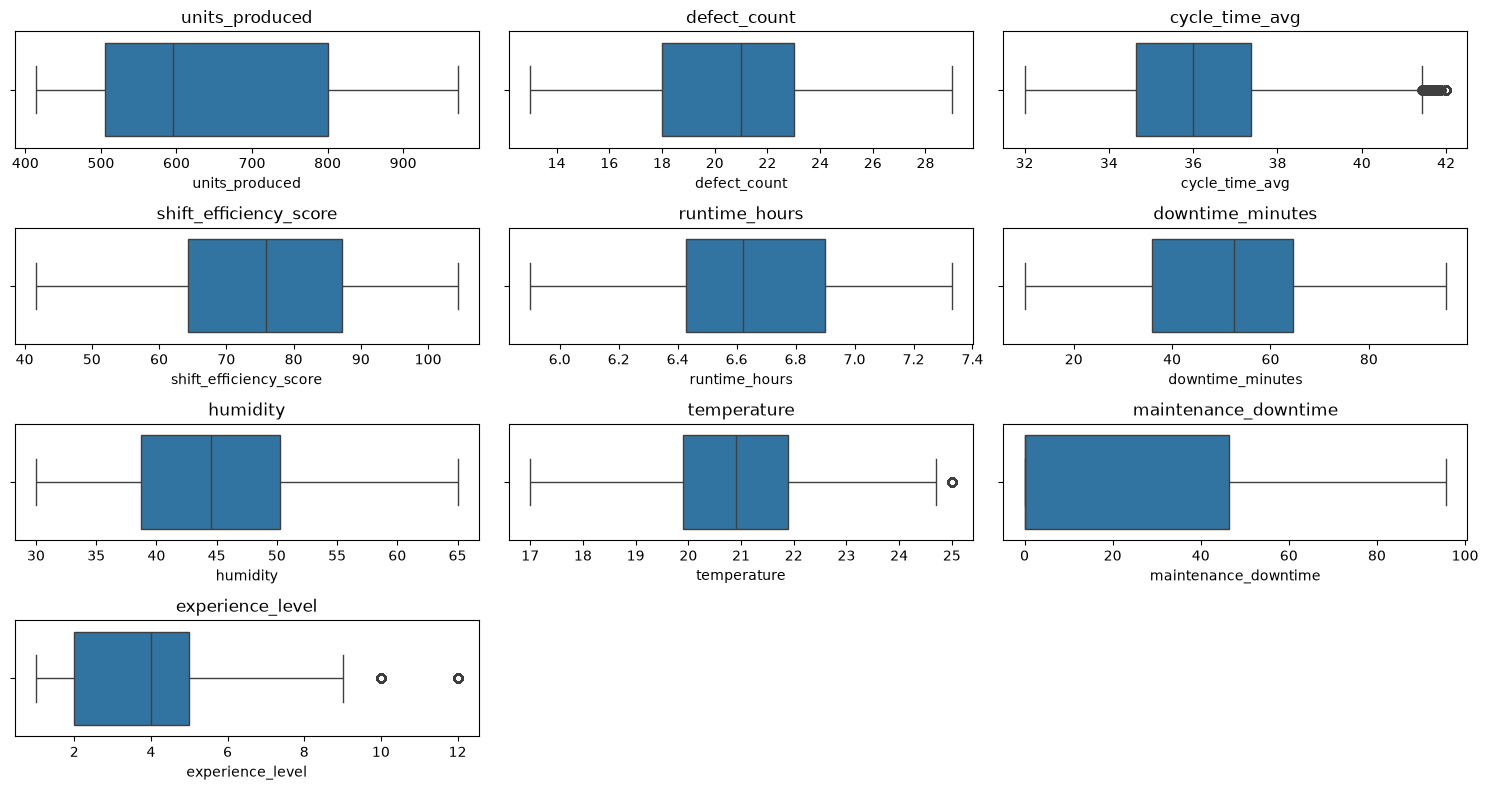

In [498]:
plt.figure(figsize=(15, 8))

for idx, col_name in enumerate(numerical_columns):
    position = int(idx + 1)
    plt.subplot(4, 3, position)
    sns.boxplot(data= shift_data, x=col_name)
    plt.title(str(col_name))
plt.tight_layout()
plt.show()   

In [499]:
# categorical Variables Analysis

categorical_columns = [
    "shift_name","skill_category","machine_status","issue_type",
    "defect_type","severity","inspection_result"
]

for columns in categorical_columns:
    print("Value counts for each categorical columns")
    print(shift_data[columns].value_counts())

Value counts for each categorical columns
shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for each categorical columns
skill_category
Intermediate    161685
Junior           56638
Senior           54664
Expert           23347
Name: count, dtype: int64
Value counts for each categorical columns
machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
Value counts for each categorical columns
issue_type
no issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for each categorical columns
defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
Value counts for each categorical columns
severity
Minor       207323
Major        74329
Critical     14682
Name: count, dtype: int64
Value counts for each categorical c

NEXT IS TO VISUALIZE THE CATEGRICAL COLUMNS

C:\Users\pc\AppData\Local\Temp\ipykernel_9836\1450909586.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= counts, x=col, y="count", palette="coolwarm", ax= axes[i])
C:\Users\pc\AppData\Local\Temp\ipykernel_9836\1450909586.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= counts, x=col, y="count", palette="coolwarm", ax= axes[i])
C:\Users\pc\AppData\Local\Temp\ipykernel_9836\1450909586.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= counts, x=col, y="count", palette="coolwarm", ax= axes[i])
C:\Users\pc\AppData\Lo

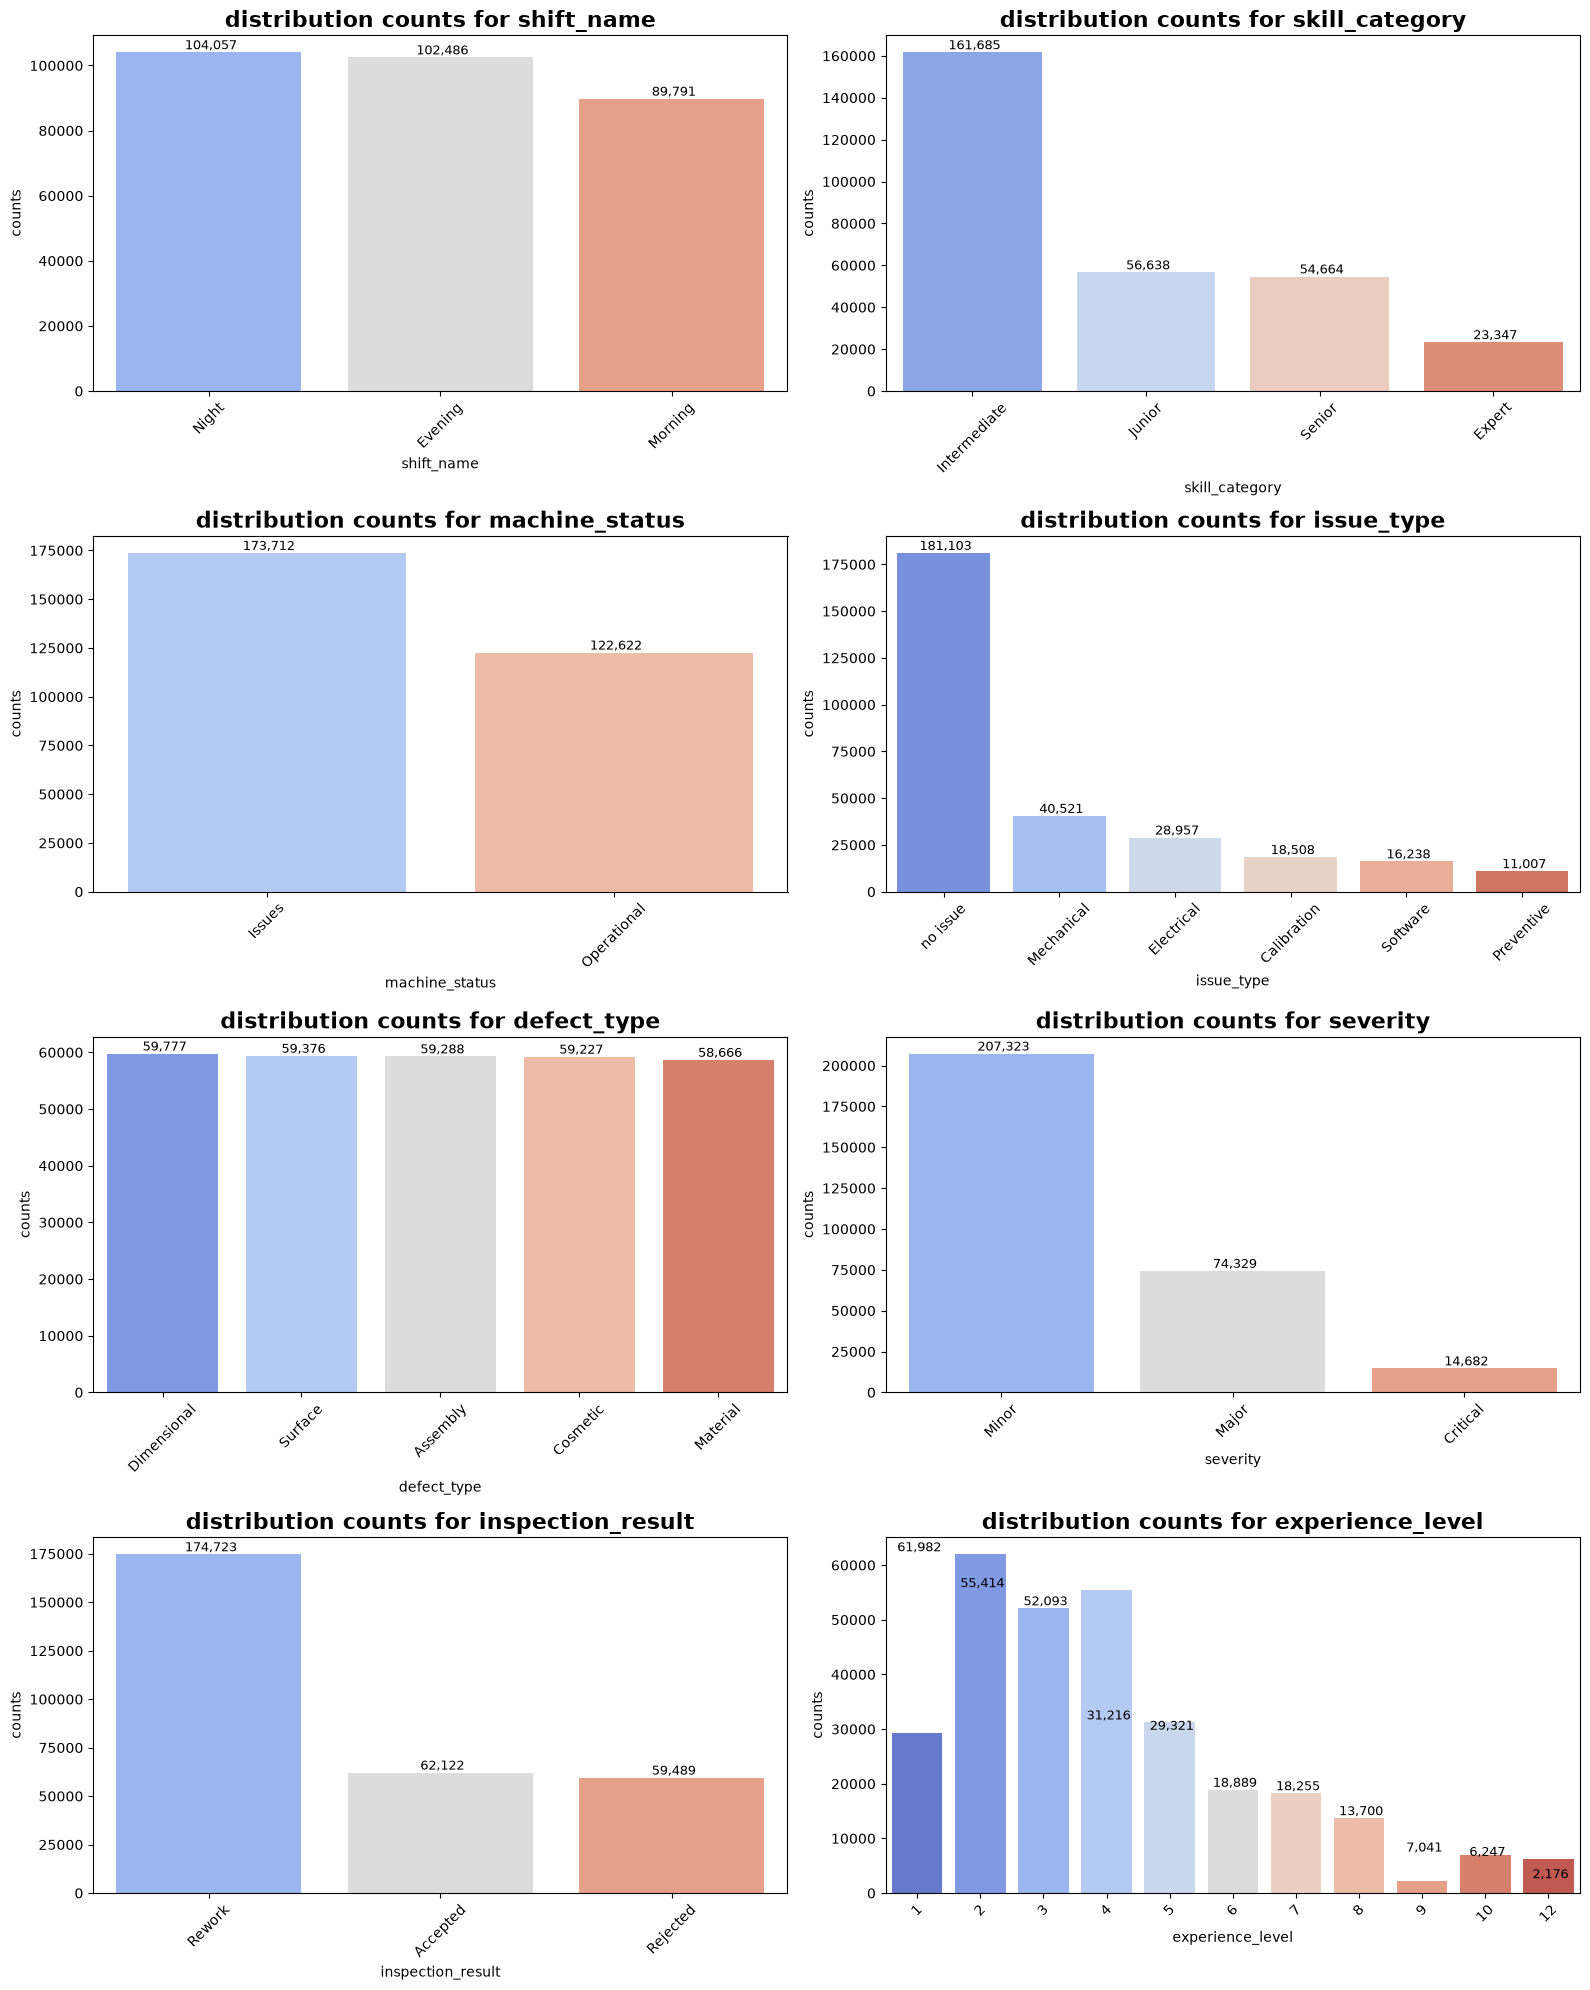

In [500]:
import seaborn as sns
import matplotlib.pyplot as plt



categorical_columns = [
    "shift_name","skill_category","machine_status","issue_type",
    "defect_type","severity","inspection_result","experience_level"
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    counts = shift_data[col].value_counts().reset_index()
    counts.columns = [col, "count"]

    sns.barplot(data= counts, x=col, y="count", palette="coolwarm", ax= axes[i])

    axes[i].tick_params(axis = "x", rotation = 45)
    axes[i].set_title(f"distribution counts for {col}", fontsize = 16, fontweight = "bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("counts")
    # let add value to the subplot
    for j, v in enumerate(counts["count"]):
        axes[i].text(j, v, f'{v: ,}', ha='center', va='bottom', fontsize= 9)


plt.tight_layout()
plt.show()





NOTE the experience_level is not a categorical Varible just to see the distribution

Since we are dealing with shift performance ultimization one of our poririty is to do Analysis the whole shift data. 
maintenance flag analysis
so we are doing analysis before optimization

In [501]:
Maintenance_grouped = shift_data.groupby('maintenance_flag')[numerical_columns].mean()
Maintenance_grouped

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,humidity,temperature,maintenance_downtime,experience_level
maintenance_flag,,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,44.572548,20.900962,13.520254,4.141962
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,44.613007,20.860356,53.701075,3.688321


Note 0 is no maintence don while 1 mean maintenance was carried out
we can see how maintenance flag affect the production as per the key colmns indicated in table repesented.
let visualize th table in seaborn 

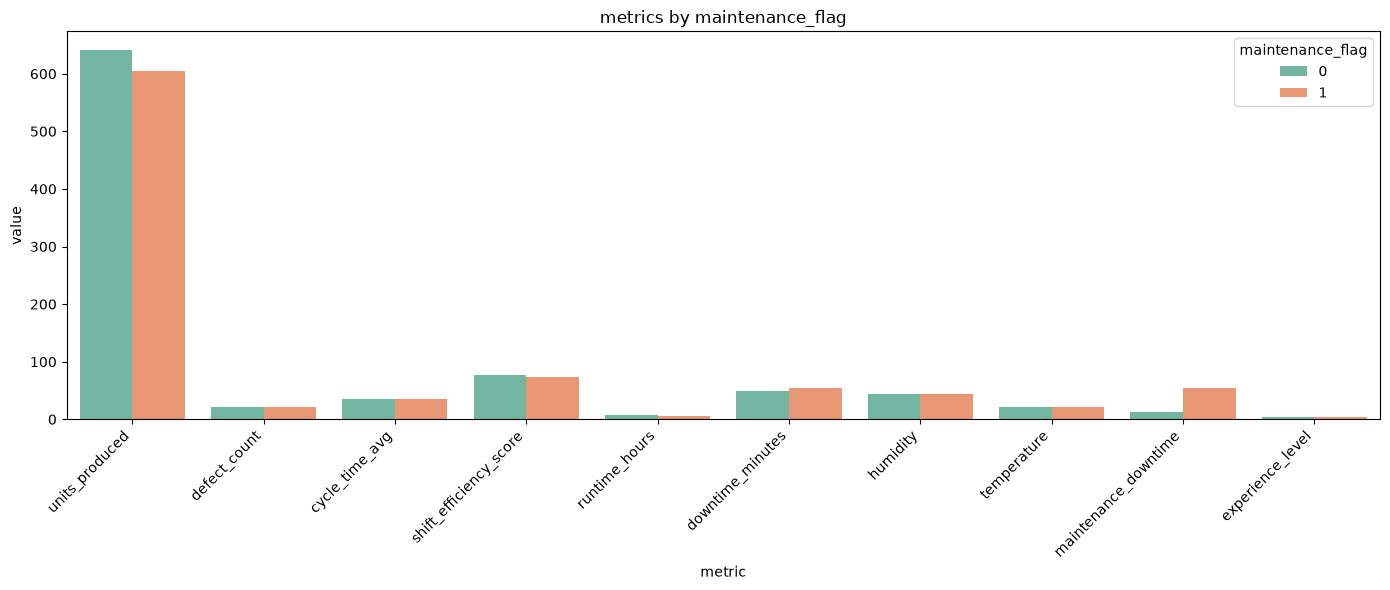

In [502]:
import seaborn as sns
import matplotlib.pyplot as plt
# we are using maintenance_grouped_plot

maintenance_grouped_plot = Maintenance_grouped.reset_index()

Maintenance_grouped_melt = maintenance_grouped_plot.melt(
    id_vars=['maintenance_flag'],
    var_name= 'metric',
    value_name= 'value'
)

plt.figure(figsize=(14, 6))

sns.barplot(data = Maintenance_grouped_melt, x= 'metric', y= 'value', hue= 'maintenance_flag',palette= 'Set2')

plt.xticks(rotation= 45, ha = 'right')
plt.title('metrics by maintenance_flag')
plt.legend(title = 'maintenance_flag')
plt.tight_layout()
plt.show()

Shift Performance ANALYSIS


In [503]:
shift_kpi = shift_data.groupby('shift_name').agg({
    'units_produced':['mean','sum'], 
    'cycle_time_avg':'mean',
    'defect_count':['mean','sum'],
    'downtime_minutes': ['mean', 'sum'],
    'shift_efficiency_score': 'mean'
}).reset_index()

shift_kpi.columns = ['shift_name', 'average_units_produced','total_unit_produced','average_cycle_time',
                    'average_defect_counts', 'total_defect_counts', 'average_downtime_minutes', 'total_downtime_minutes',
                    'average_shift_efficiency_score']
shift_kpi

,shift_name,average_units_produced,total_unit_produced,average_cycle_time,average_defect_counts,total_defect_counts,average_downtime_minutes,total_downtime_minutes,average_shift_efficiency_score
0,Evening,601.050543,61599266,36.025551,21.329079,2185932,50.569570,5182672.96,76.737957
1,Morning,846.926073,76046339,35.999287,18.749151,1683505,29.086002,2611661.18,90.869944
2,Night,484.765119,50443204,36.028043,21.670998,2255019,67.857893,7061088.73,61.164965


Th business assumptions of the following outcome is as follows

By the analysis the metrics, Rows 2 the morning shift is vastly outperformes the others, while Row 3 represents a critical operational bottleneck

Morning Shift is the most productive and efficient: It has the highest average and total units_produced, the highest average shift_efficiency_score, and the lowest average and total defect_count and downtime_minutes. its achieves the highest efficiency 
90.88% Has the lowest average downtime (29.08mins) and lowest defect counts (1.68M) The business impact this shift maximizies profitability and sets the baselines for best practices


Night Shift faces significant challenges: It has the lowest average units_produced and shift_efficiency_score, and the highest average defect_count and downtime_minutes. This suggests potential issues with staffing, machine conditions, or supervision during this shift. it suffers from the lowest efficiency (61.16%). Experience more than double the total downtime (7.06Mins) compares to the morning shift. business insight high downtime and defect rates 2.25m lead to missed delivery deadlines wasted raw materials and inflated labor cost.

Evening Shift is moderately performing: It falls between the Morning and Night shifts in terms of productivity and efficiency, but has higher defect counts and downtime compared to the Morning shift.

Cycle time is relatively consistent across shifts: The cycle_time_avg is very similar for all shifts, indicating that the fundamental process speed per unit is not a major differentiating factor, but the total cycle time sum varies due to the volume of units processed.

These insights can be used to further investigate the reasons behind performance differences and implement targeted improvements for each shift.

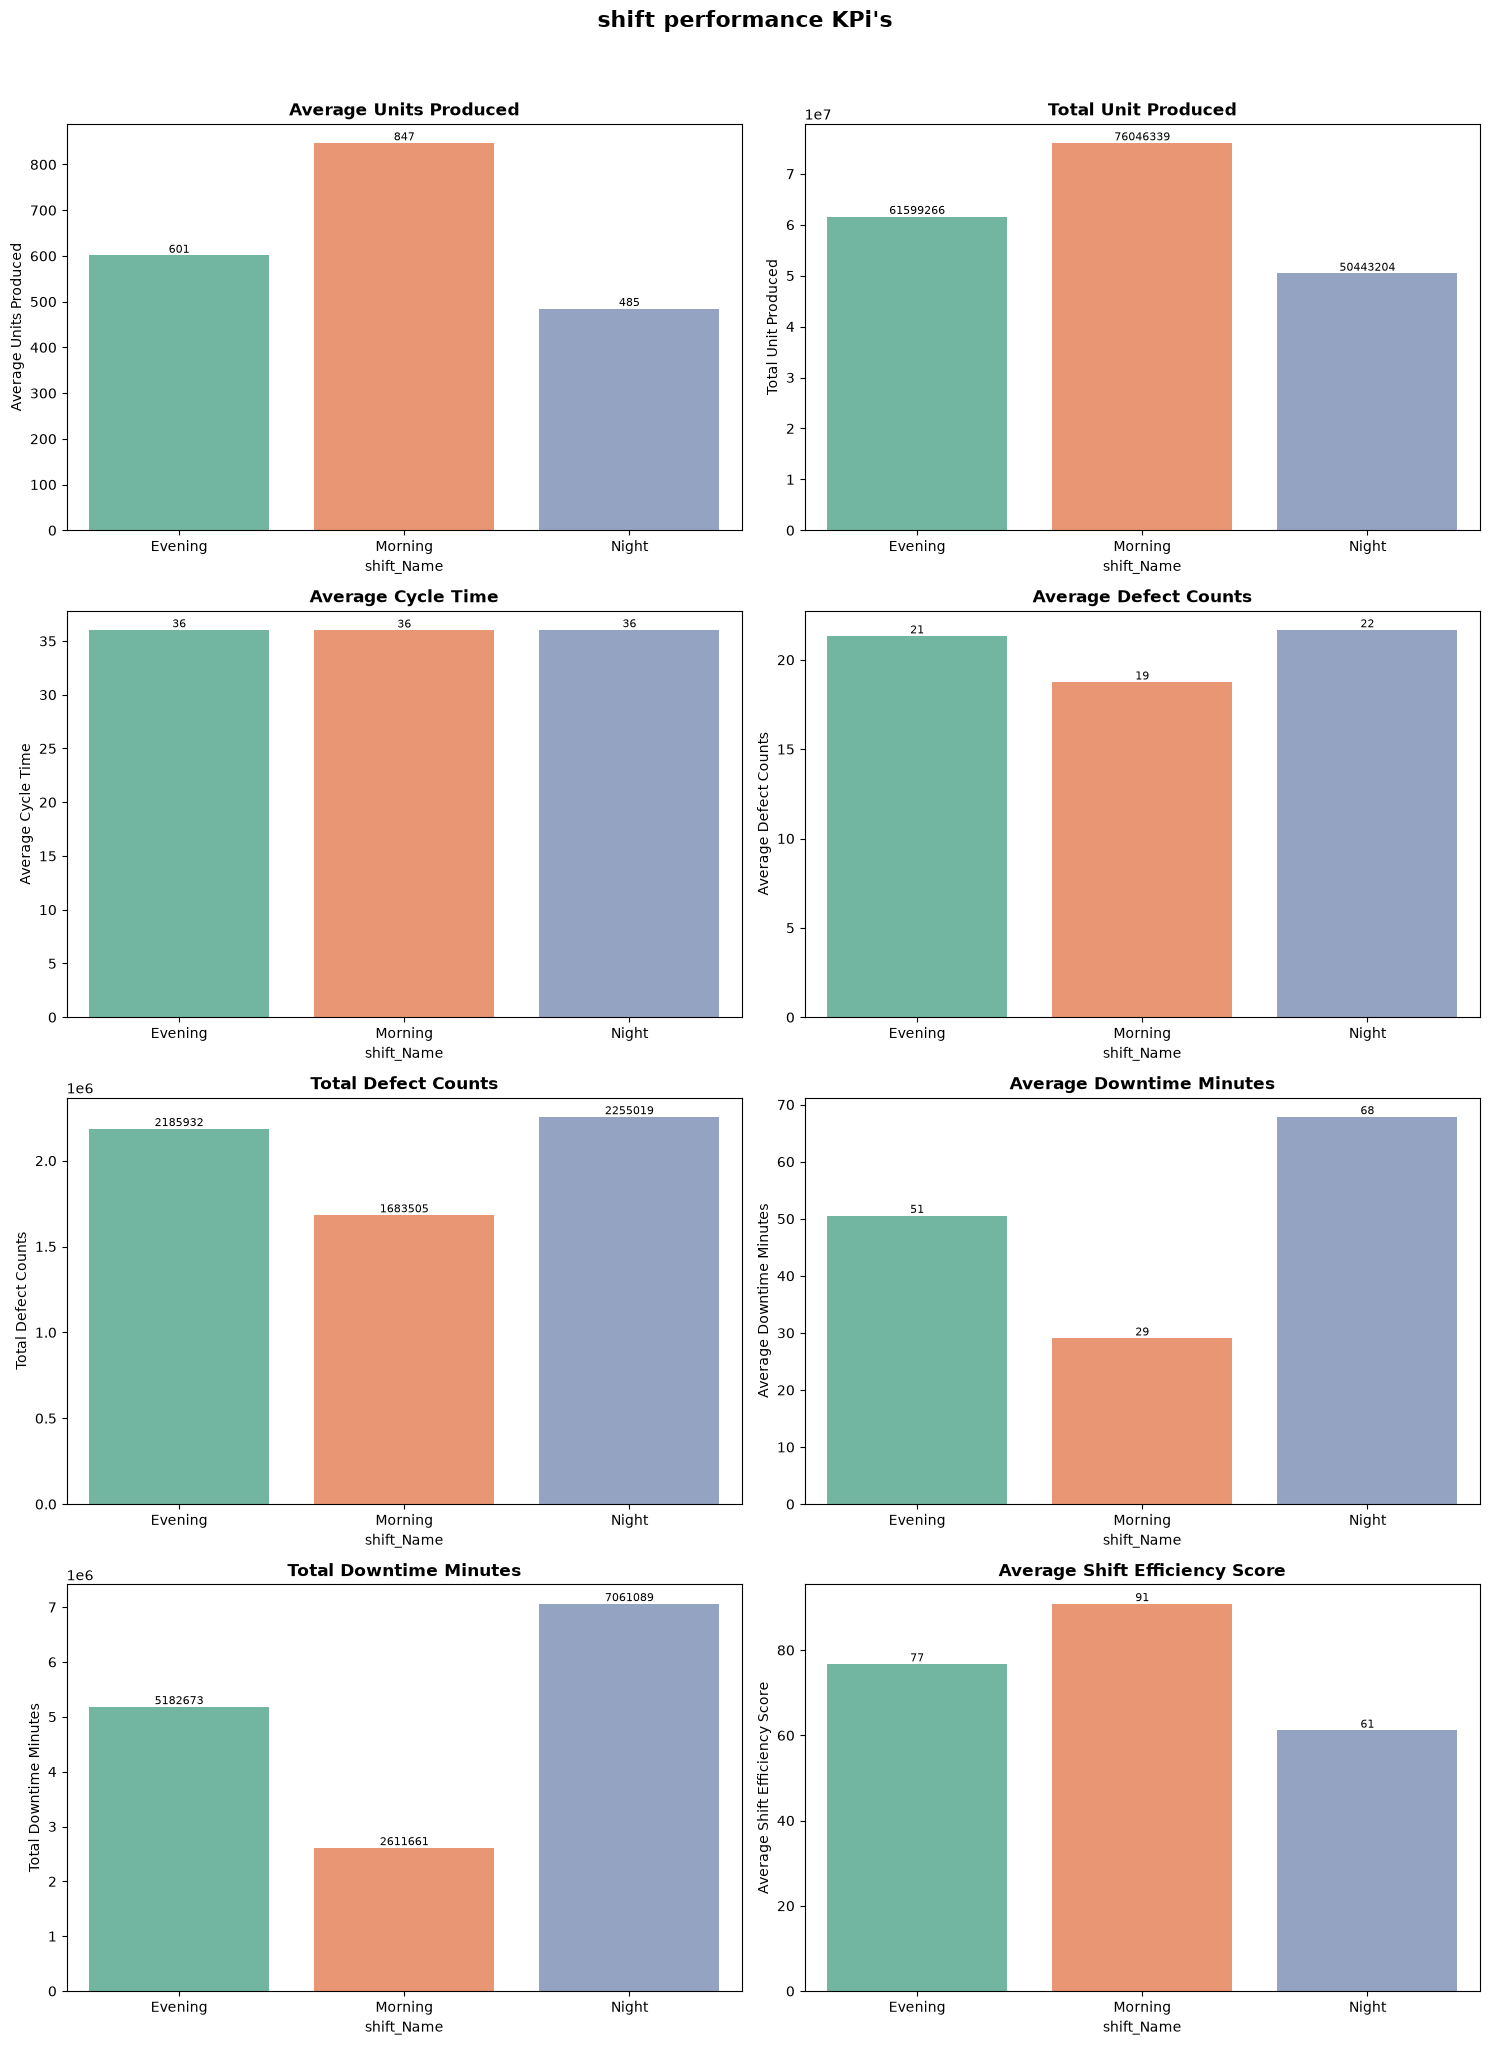

In [504]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(15, 20))

axes = axes.flatten()


metrics = ["average_units_produced",
           'total_unit_produced','average_cycle_time',
           'average_defect_counts', 'total_defect_counts', 
           'average_downtime_minutes','total_downtime_minutes',
           'average_shift_efficiency_score']


for i, metric in enumerate(metrics):
    sns.barplot (data= shift_kpi, x ='shift_name', y = metric, 
                hue = 'shift_name', palette= "Set2", legend=False, ax= axes[i])
    axes[i].set_title(f'{metric.replace("_", " ").title()}', fontsize=12, fontweight = 'bold')
    axes[i].set_xlabel('shift_Name')
    axes[i].set_ylabel(metric.replace("_", " ").title())

    ## add value labels on the bar
    for j, v in enumerate(shift_kpi[metric]):
        if 'units' in metric:
            axes[i].text(j, v,f'{v:.0f}', ha = 'center', va= 'bottom', fontsize=8)

        else:
            axes[i].text(j, v,f'{v:.0f}', ha= 'center', va ='bottom', fontsize= 8)    


            

plt.suptitle("shift performance KPi's", fontsize= 16, fontweight= 'bold', y= 1.02 )
plt.tight_layout()
plt.show()

LET CHECK OUTPUT PER HOUR FOR EACH OF THE SHIFT

This covers the hours the machine within the each shift

In [505]:
shift_data['total_machine_hours'] = shift_data['runtime_hours'] + (shift_data['downtime_minutes'] / 60)

output_per_hour = (
    shift_data.groupby('shift_name').apply(lambda x: x['units_produced'].sum() / x['total_machine_hours'].sum())
    .rename('output_per_hour')
)

output_per_hour

C:\Users\pc\AppData\Local\Temp\ipykernel_9836\1704388955.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shift_data.groupby('shift_name').apply(lambda x: x['units_produced'].sum() / x['total_machine_hours'].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

using a pie chart to visualize output_per_hour

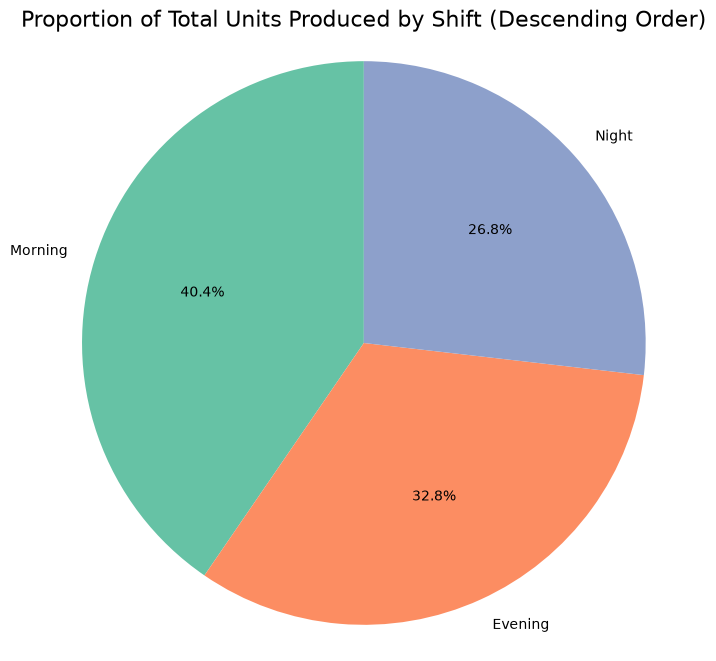

In [506]:
import matplotlib.pyplot as plt

# Prepare data for the pie chart and sort in descending order
pie_data_sorted = shift_kpi[['shift_name', 'total_unit_produced']].sort_values(by='total_unit_produced', ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(pie_data_sorted['total_unit_produced'], labels=pie_data_sorted['shift_name'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Proportion of Total Units Produced by Shift (Descending Order)', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Availability Analysis based on Machine runtime


In [507]:
availability = (
    shift_data.groupby('shift_name')
    .apply(lambda x: x['runtime_hours'].sum() /
           (x['runtime_hours'].sum() + (x['downtime_minutes'].sum() / 60)))
           .rename('availability')

)

availability

C:\Users\pc\AppData\Local\Temp\ipykernel_9836\706857209.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['runtime_hours'].sum() /


shift_name
Evening    0.887622
Morning    0.935362
Night      0.849205
Name: availability, dtype: float64

let visualize in a graph

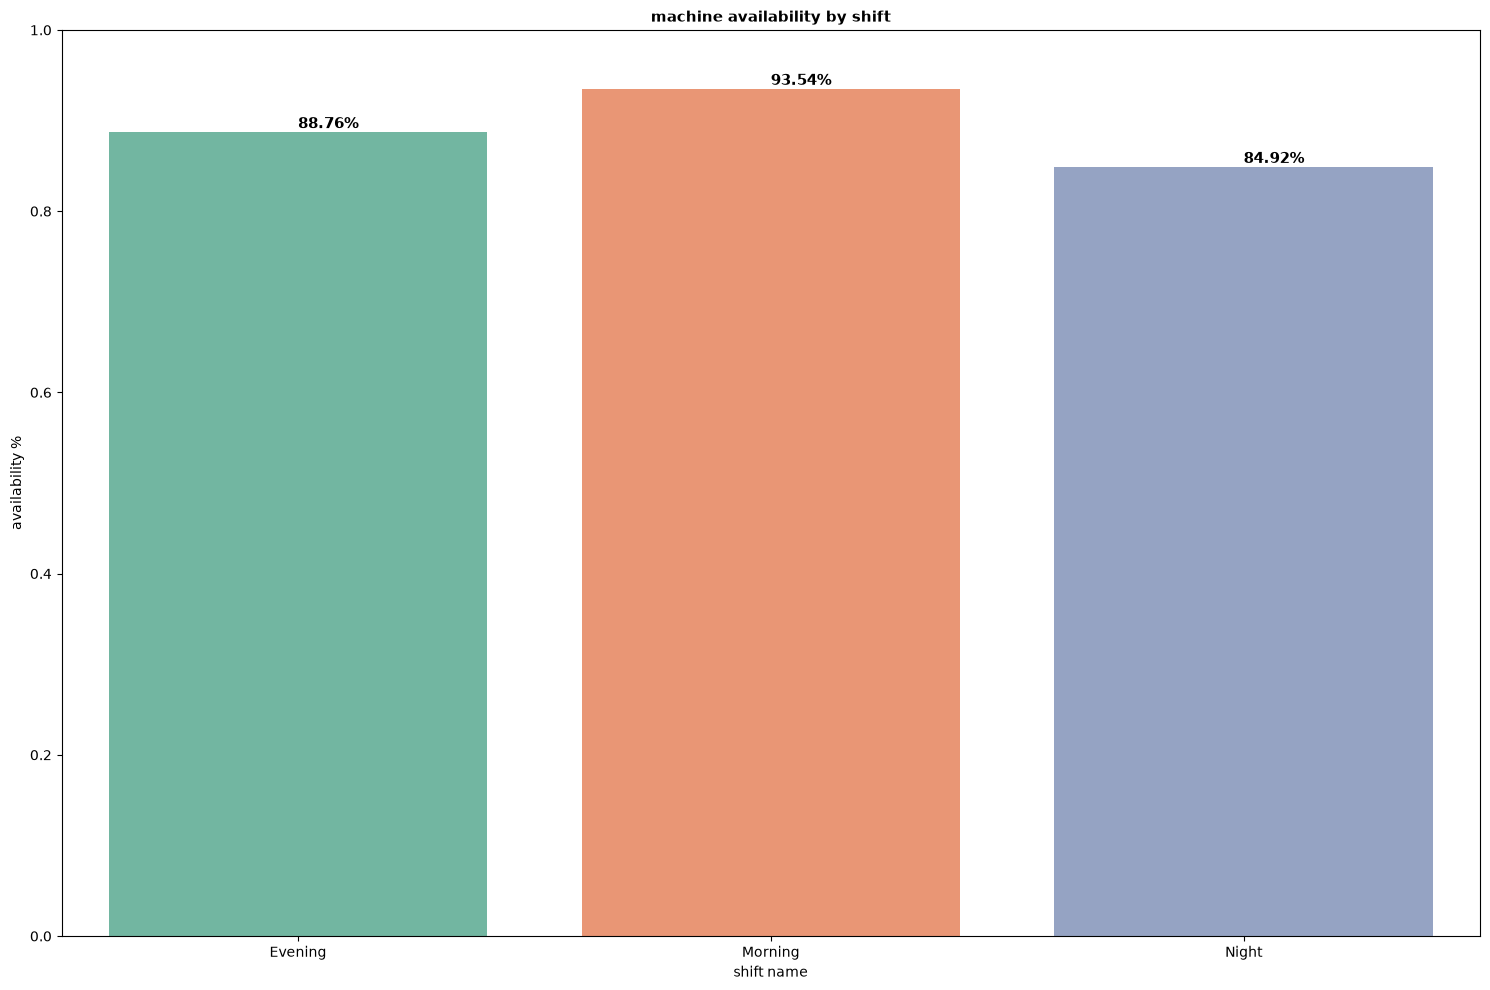

In [554]:
availability_df = availability.reset_index()

plt.figure(figsize= (15, 10))

sns.barplot(data=availability_df, x ='shift_name', y ='availability',
            hue = 'shift_name', palette= 'Set2', legend= False)

plt.title('machine availability by shift', fontsize=11, fontweight= 'bold')
plt.xlabel('shift name')
plt.ylabel('availability %') 

plt.ylim(0, 1)

for i, v, in enumerate(availability_df['availability']):
    plt.text(i, v, f'{v:.2%}', va= 'bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()